In [1]:
path = "Olist retention analysis/data/raw/"

In [2]:
plt.savefig('Olist retention analysis/output/customer_status_breakdown.png', dpi=150)

NameError: name 'plt' is not defined

In [3]:
import os
print(os.path.exists("Olist retention analysis/data/raw/olist_customers_dataset.csv"))


False


In [4]:
import os
print(os.listdir("Olist retention analysis"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'Olist retention analysis'

In [5]:
import os
print("CWD:", os.getcwd())
print("Here:", os.listdir('.'))

CWD: c:\Users\oyo\Desktop\Business Analyst\Olist retention analysis\notebook
Here: ['01_data_exploration.ipynb']


In [7]:
path = "../data/raw/"

In [6]:
print(os.listdir('..'))

['Data', 'notebook', 'output', 'venv']


In [8]:
print(os.listdir('../Data'))


['processed', 'raw']


In [1]:
import pandas as pd

path = "../Data/raw/"

customers = pd.read_csv(path + "olist_customers_dataset.csv")
orders = pd.read_csv(path + "olist_orders_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")
products = pd.read_csv(path + "olist_products_dataset.csv")
sellers = pd.read_csv(path + "olist_sellers_dataset.csv")
geo = pd.read_csv(path + "olist_geolocation_dataset.csv")
translation = pd.read_csv(path + "product_category_name_translation.csv")

for name, df in [("customers", customers), ("orders", orders), ("order_items", order_items),
                  ("payments", payments), ("reviews", reviews), ("products", products),
                  ("sellers", sellers), ("geo", geo), ("translation", translation)]:
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} cols")

customers: 99441 rows, 5 cols
orders: 99441 rows, 8 cols
order_items: 112650 rows, 7 cols
payments: 103886 rows, 5 cols
reviews: 99224 rows, 7 cols
products: 32951 rows, 9 cols
sellers: 3095 rows, 4 cols
geo: 1000163 rows, 5 cols
translation: 71 rows, 2 cols


In [2]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
print("Date range:", orders['order_purchase_timestamp'].min(), "to", orders['order_purchase_timestamp'].max())
print(orders['order_status'].value_counts())

Date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [5]:
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

orders_cust = orders_delivered.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)
print(orders_cust.shape)

(96478, 9)


In [7]:
order_value = order_items.groupby('order_id').agg(
    order_revenue=('price', 'sum'),
    order_freight=('freight_value', 'sum')
).reset_index()

orders_full = orders_cust.merge(order_value, on='order_id', how='left')

customer_summary = orders_full.groupby('customer_unique_id').agg(
    first_purchase=('order_purchase_timestamp', 'min'),
    last_purchase=('order_purchase_timestamp', 'max'),
    order_count=('order_id', 'nunique'),
    total_spend=('order_revenue', 'sum')
).reset_index()

print(customer_summary.shape)
customer_summary.describe()

(93358, 5)


,first_purchase,last_purchase,order_count,total_spend
count,93358,93358,93358.000000,93358.000000
mean,2018-01-01 12:18:32.380503,2018-01-04 03:47:36.045363,1.033420,141.621480
min,2016-09-15 12:16:38,2016-09-15 12:16:38,1.000000,0.850000
25%,2017-09-13 15:41:22.500000,2017-09-17 18:25:15,1.000000,47.650000
50%,2018-01-20 06:48:07,2018-01-23 00:12:12.500000,1.000000,89.730000
75%,2018-05-05 14:13:38.250000,2018-05-07 17:22:34.750000,1.000000,154.737500
max,2018-08-29 15:00:37,2018-08-29 15:00:37,15.000000,13440.000000
std,NaN,NaN,0.209097,215.694014


In [8]:
snapshot_date = orders_full['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

customer_summary['recency_days'] = (snapshot_date - customer_summary['last_purchase']).dt.days
customer_summary['tenure_days'] = (customer_summary['last_purchase'] - customer_summary['first_purchase']).dt.days

Snapshot date: 2018-08-30 15:00:37


In [9]:
repeat_customers = customer_summary[customer_summary['order_count'] > 1]
churn_threshold = repeat_customers['tenure_days'].quantile(0.90)
print(f"90th percentile repeat-purchase gap: {churn_threshold:.0f} days")

def classify_status(row):
    if row['order_count'] == 1 and row['recency_days'] > churn_threshold:
        return 'One-time (lapsed)'
    elif row['order_count'] == 1:
        return 'One-time (recent)'
    elif row['recency_days'] <= churn_threshold:
        return 'Active repeat'
    else:
        return 'Churned repeat'

customer_summary['status'] = customer_summary.apply(classify_status, axis=1)
customer_summary['status'].value_counts()

90th percentile repeat-purchase gap: 265 days


status
One-time (recent)    53559
One-time (lapsed)    36998
Active repeat         1783
Churned repeat        1018
Name: count, dtype: int64

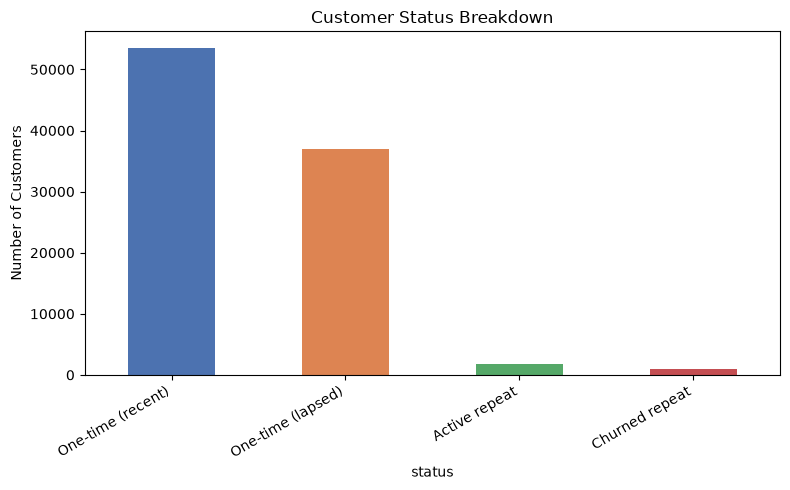

In [10]:
import matplotlib.pyplot as plt

status_counts = customer_summary['status'].value_counts()
plt.figure(figsize=(8,5))
status_counts.plot(kind='bar', color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.title('Customer Status Breakdown')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../output/customer_status_breakdown.png', dpi=150)
plt.show()

In [11]:
customer_summary['R_score'] = pd.qcut(customer_summary['recency_days'], 5, labels=[5,4,3,2,1])
customer_summary['F_score'] = pd.qcut(customer_summary['order_count'].rank(method='first'), 5, labels=[1,2,3,4,5])
customer_summary['M_score'] = pd.qcut(customer_summary['total_spend'], 5, labels=[1,2,3,4,5])

customer_summary['RFM_score'] = (
    customer_summary['R_score'].astype(str) +
    customer_summary['F_score'].astype(str) +
    customer_summary['M_score'].astype(str)
)

customer_summary[['recency_days','R_score','order_count','F_score','total_spend','M_score','RFM_score']].head(10)

,recency_days,R_score,order_count,F_score,total_spend,M_score,RFM_score
0,112,4,1,1,129.90,4,414
1,115,4,1,1,18.90,1,411
2,537,1,1,1,69.00,2,112
3,321,2,1,1,25.99,1,211
4,288,2,1,1,180.00,5,215
5,146,4,1,1,154.00,4,414
6,132,4,1,1,27.99,1,411
7,183,3,1,1,382.00,5,315
8,543,1,1,1,135.00,4,114
9,170,4,1,1,104.90,3,413


In [12]:
def rfm_segment(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 4 and f <= 2:
        return 'New / Promising'
    elif r <= 2 and f >= 4:
        return 'At Risk (was loyal)'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    elif r == 3:
        return 'Needs Attention'
    elif r >= 4 and m >= 4:
        return 'Big Spenders (recent)'
    else:
        return 'Other'

customer_summary['segment'] = customer_summary.apply(rfm_segment, axis=1)
customer_summary['segment'].value_counts()

segment
Other                    20465
Needs Attention          18709
New / Promising          14984
Champions                14961
At Risk (was loyal)      14803
Lost                      6478
Big Spenders (recent)     2958
Name: count, dtype: int64

In [13]:
def f_score_manual(order_count):
    if order_count == 1:
        return 1
    elif order_count == 2:
        return 3
    elif order_count == 3:
        return 4
    else:  # 4+
        return 5

customer_summary['F_score'] = customer_summary['order_count'].apply(f_score_manual)

# Recalculate RFM_score and segment with the corrected F_score
customer_summary['RFM_score'] = (
    customer_summary['R_score'].astype(str) +
    customer_summary['F_score'].astype(str) +
    customer_summary['M_score'].astype(str)
)

customer_summary['segment'] = customer_summary.apply(rfm_segment, axis=1)
customer_summary['segment'].value_counts()

segment
New / Promising          36224
Other                    21677
Needs Attention          18709
Lost                     15734
Big Spenders (recent)      823
Champions                  122
At Risk (was loyal)         69
Name: count, dtype: int64

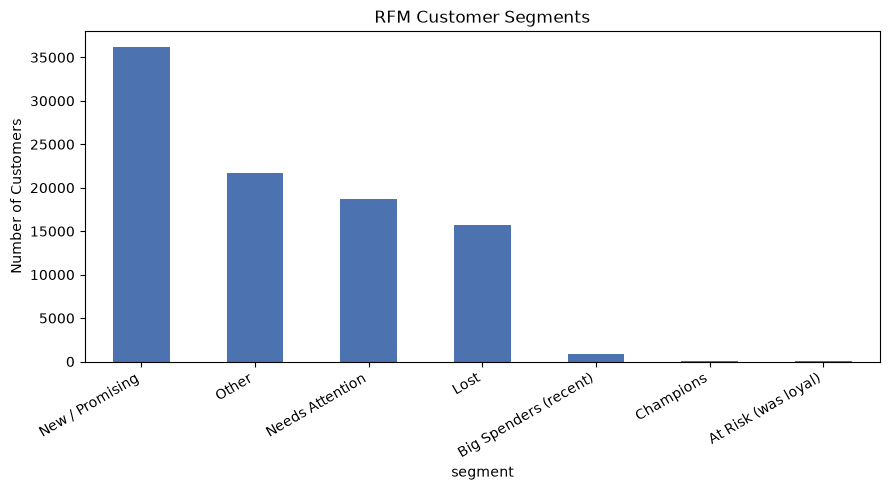

In [14]:
plt.figure(figsize=(9,5))
customer_summary['segment'].value_counts().plot(kind='bar', color='#4C72B0')
plt.title('RFM Customer Segments')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../output/rfm_segments.png', dpi=150)
plt.show()

In [15]:
customer_summary.to_csv('../Data/processed/customer_rfm_summary.csv', index=False)
print("Saved:", customer_summary.shape)

Saved: (93358, 13)
